In [2]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import h5py # Standard format for pre-generated crowd density maps
import numpy as np

# ---------------------------------------------------------
# 1. The 3 Attention Branches
# ---------------------------------------------------------
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction_ratio, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        y = torch.cat([avg_out, max_out], dim=1)
        y = self.conv(y)
        return x * self.sigmoid(y)

class ScaleAttention(nn.Module):
    def __init__(self, in_channels):
        super(ScaleAttention, self).__init__()
        self.branch1 = nn.Conv2d(in_channels, in_channels // 3, kernel_size=3, padding=1, dilation=1)
        self.branch2 = nn.Conv2d(in_channels, in_channels // 3, kernel_size=3, padding=2, dilation=2)
        self.branch3 = nn.Conv2d(in_channels, in_channels // 3, kernel_size=3, padding=3, dilation=3)
        self.fuse = nn.Conv2d(in_channels // 3 * 3, in_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out1 = F.relu(self.branch1(x))
        out2 = F.relu(self.branch2(x))
        out3 = F.relu(self.branch3(x))
        y = torch.cat([out1, out2, out3], dim=1)
        y = self.sigmoid(self.fuse(y))
        return x * y

# ---------------------------------------------------------
# 2. The Model (MobileNetV3 + MAN)
# ---------------------------------------------------------
class EdgeCrowdCounter(nn.Module):
    def __init__(self):
        super(EdgeCrowdCounter, self).__init__()
        mobilenet = models.mobilenet_v3_large(pretrained=True)
        self.backbone = mobilenet.features
        in_features = 960 
        
        self.channel_att = ChannelAttention(in_features)
        self.spatial_att = SpatialAttention()
        self.scale_att = ScaleAttention(in_features)
        
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(in_features, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        
        self.regression_head = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        features = self.backbone(x)
        ca_out = self.channel_att(features)
        sa_out = self.spatial_att(features)
        sca_out = self.scale_att(features)
        
        fused_features = ca_out + sa_out + sca_out
        fused_features = self.fusion_conv(fused_features)
        density_map = self.regression_head(fused_features)
        return F.softplus(density_map)

In [3]:
class DensityAwareLoss(nn.Module):
    def __init__(self, alpha=100.0):
        super(DensityAwareLoss, self).__init__()
        self.alpha = alpha # Weight factor for dense regions

    def forward(self, pred, target):
        # Calculate standard squared error
        mse = (pred - target) ** 2
        # Create a weight map based on the ground truth density
        # Where target is high, the weight is high. Where target is 0, weight is 1.
        weight_map = 1.0 + (self.alpha * target)
        # Apply weights and calculate mean
        loss = torch.mean(mse * weight_map)
        return loss

In [4]:
class CrowdDataset(Dataset):
    def __init__(self, img_dir, gt_dir, transform=None):
        self.transform = transform
        self.valid_data = [] # We will store matching (image, ground_truth) pairs here
        
        # Find all JPGs in the image directory
        all_imgs = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        
        for img_path in all_imgs:
            filename = os.path.basename(img_path)
            name, _ = os.path.splitext(filename)
            
            # Look for the matching .h5 file we generated earlier
            h5_path = os.path.join(gt_dir, f'{name}.h5')
            
            # ONLY add to our dataset if BOTH files exist
            if os.path.exists(h5_path):
                self.valid_data.append((img_path, h5_path))
                
        print(f"Dataset Loaded: Found {len(self.valid_data)} valid Image-Mask pairs.")

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        # Unpack the verified matching pair
        img_path, gt_path = self.valid_data[idx]
        
        # Load Image
        img = Image.open(img_path).convert('RGB')
        
        # Load Ground Truth Density Map safely
        with h5py.File(gt_path, 'r') as gt_file:
            target = np.asarray(gt_file['density'])
            
        target = torch.from_numpy(target).unsqueeze(0) # Add channel dim
        
        if self.transform:
            img = self.transform(img)
            
        return img, target

# Basic transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
import os
import glob
import h5py
import numpy as np
import scipy.io as io
import scipy.ndimage
import re
from PIL import Image

print("Searching for ShanghaiTech Part B in Kaggle input...")

# 1. Automatically find the correct image directory
search_path = '/kaggle/input/**/*.jpg'
all_jpgs = glob.glob(search_path, recursive=True)

# Filter for ShanghaiTech Part B Train images
train_imgs = [p for p in all_jpgs if 'part_B' in p and 'train_data' in p]

if len(train_imgs) == 0:
    print("❌ ERROR: Could not find Part B training images.")
else:
    # 2. Extract the base directories automatically
    img_dir = os.path.dirname(train_imgs[0])
    gt_dir = img_dir.replace('images', 'ground-truth') 
    
    print(f"✅ Found Image Directory: {img_dir}")
    print(f"✅ Target Ground Truth Directory: {gt_dir}")

    # --- THE BULLETPROOF FIX ---
    # Map all available .mat files by their numerical ID to avoid case-sensitivity issues
    all_gt_files = os.listdir(gt_dir)
    mat_dict = {}
    for f in all_gt_files:
        match = re.search(r'\d+', f)
        if match and f.lower().endswith('.mat'):
            mat_dict[match.group()] = f
    # ---------------------------

    # 3. Create a folder to save the new .h5 maps
    H5_OUTPUT_DIR = '/kaggle/working/shanghaitech_h5/train'
    os.makedirs(H5_OUTPUT_DIR, exist_ok=True)
    print(f"📁 Creating .h5 heatmaps in: {H5_OUTPUT_DIR}")

    # 4. Generate the Density Maps safely
    success_count = 0
    missing_mat_count = 0
    
    for img_path in train_imgs:
        filename = os.path.basename(img_path)
        
        # Extract the number from the image filename (e.g., 'IMG_1.jpg' -> '1')
        img_num_match = re.search(r'\d+', filename)
        
        if not img_num_match or img_num_match.group() not in mat_dict:
            print(f"⚠️ Could not find matching ground truth for image: {filename}")
            missing_mat_count += 1
            continue
            
        # Safely grab the exact filename as it exists on the Linux filesystem
        exact_mat_filename = mat_dict[img_num_match.group()]
        mat_path = os.path.join(gt_dir, exact_mat_filename)
        
        # Extract coordinates (Standard ShanghaiTech .mat structure)
        mat = io.loadmat(mat_path)
        points = mat['image_info'][0,0][0,0][0] 
        
        # Load image to get dimensions
        img = Image.open(img_path)
        w, h = img.size
        
        # Create density map
        density_map = np.zeros((h, w), dtype=np.float32)
        
        for p in points:
            x, y = int(p[0]), int(p[1])
            if y < h and x < w:
                density_map[y, x] = 1.0
                
        # Apply Gaussian filter
        density_map = scipy.ndimage.gaussian_filter(density_map, sigma=15)
        
        name, _ = os.path.splitext(filename)
        # Save as .h5
        h5_path = os.path.join(H5_OUTPUT_DIR, f'{name}.h5')
        with h5py.File(h5_path, 'w') as hf:
            hf['density'] = density_map
            
        success_count += 1
            
    print("---------------------------------------------------------")
    print(f"🎉 Success! ACTUALLY generated {success_count} density heatmaps.")
    if missing_mat_count > 0:
        print(f"⚠️ Warning: Skipped {missing_mat_count} images.")
    print("---------------------------------------------------------")

In [ ]:
import os
check_dir = '/kaggle/working/shanghaitech_h5/train'

if os.path.exists(check_dir):
    files = os.listdir(check_dir)
    print(f"✅ The folder exists and contains {len(files)} files!")
    if len(files) > 0:
        print(f"First few files: {files[:5]}")
else:
    print("❌ The folder does NOT exist. You need to re-run Step 4!")

In [ ]:
# ---------------------------------------------------------
# Kaggle Paths & Hyperparameters
# ---------------------------------------------------------
# UPDATE THESE PATHS based on how the dataset mounts in your Kaggle notebook

TRAIN_IMG_DIR = '/kaggle/input/datasets/hosammhmdali/shanghai-tech-dataset-part-a-and-part-b/ShanghaiTech/part_B/train_data/images'
TRAIN_GT_DIR = '/kaggle/working/shanghaitech_h5/train'
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize Model, Loss, and Optimizer
model = EdgeCrowdCounter().to(device)
criterion = DensityAwareLoss(alpha=100.0)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Load Data
train_dataset = CrowdDataset(TRAIN_IMG_DIR, TRAIN_GT_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=2)

# ---------------------------------------------------------
# Resume Logic for 12-Hour Chaining
# ---------------------------------------------------------
start_epoch = 0
resume_checkpoint = None # Change this to 'model_epoch_50.pth' if resuming

if resume_checkpoint:
    ckpt_path = os.path.join(CHECKPOINT_DIR, resume_checkpoint)
    if os.path.isfile(ckpt_path):
        print(f"Resuming from {ckpt_path}")
        checkpoint = torch.load(ckpt_path, map_location=device)
        start_epoch = checkpoint['epoch'] + 1
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# ---------------------------------------------------------
# Training Loop
# ---------------------------------------------------------
num_epochs = 300
target_multiplier = 100.0 # Amplifies the microscopic density values

print("Starting Background Training...")

for epoch in range(start_epoch, num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for i, (images, targets) in enumerate(train_loader):
        images = images.to(device)
        
        # Scale up targets so the model can calculate healthy gradients
        targets = targets.to(device) * target_multiplier 
        
        # --- Sanity Check (Prints only on the very first batch) ---
        if epoch == 0 and i == 0:
            actual_count = targets.sum().item() / target_multiplier
            print(f"🔍 Sanity Check: Image 1 contains approx {actual_count:.1f} people.")
        
        # Forward pass
        outputs = model(images)
        
        # Resize output to match target shape
        outputs = F.interpolate(outputs, size=(targets.shape[2], targets.shape[3]), mode='bilinear', align_corners=False)
        
        loss = criterion(outputs, targets)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    
    # Changed to .6f to see smaller variations in the loss
    print(f"Epoch [{epoch}/{num_epochs-1}], Average Loss: {avg_loss:.9f}")
    
    # Save checkpoint every 10 epochs
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        save_path = os.path.join(CHECKPOINT_DIR, f'model_epoch_{epoch}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, save_path)
        print(f"Checkpoint saved to {save_path}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 21.1M/21.1M [00:00<00:00, 145MB/s]


✅ Model weights loaded successfully!
📊 Total people in entire frame: 359.2
------------------------------
📍 Queue 1 Count: 75.7 people
📍 Queue 2 Count: 35.9 people
📍 Queue 3 Count: 37.6 people
📍 Queue 4 Count: 43.4 people
📍 Queue 5 Count: 32.7 people
📍 Queue 6 Count: 32.4 people
📍 Queue 7 Count: 20.8 people
📍 Queue 8 Count: 16.1 people
📍 Queue 9 Count: 11.0 people
------------------------------


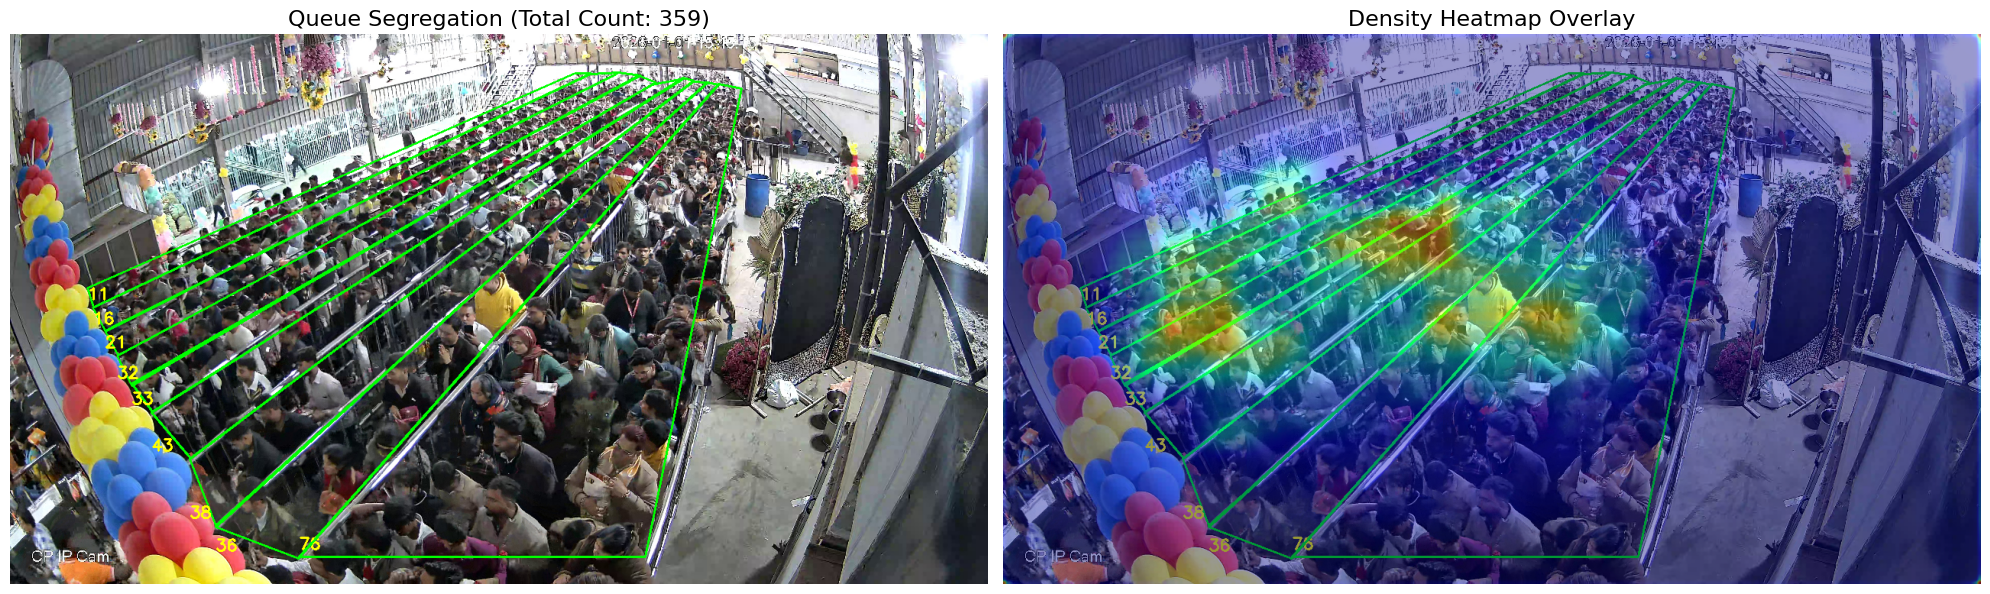

In [4]:
import cv2
import torch
import numpy as np
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Configuration & Loading
# ---------------------------------------------------------
# ⚠️ ACTION REQUIRED: Update these two paths!
MODEL_WEIGHTS_PATH = '/kaggle/input/datasets/maaujo/fine-tuned-model-weights/model_temple_finetuned.pth'#'/kaggle/input/notebooks/maaujo/notebook7cd83bb44b/checkpoints/model_epoch_299.pth' # Or whichever was your last epoch
TEST_IMAGE_PATH = '/kaggle/input/datasets/maaujo/temple-queue/frame_001.jpg' # Update with your uploaded image
TARGET_MULTIPLIER = 100.0 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize the model and load your trained weights
model = EdgeCrowdCounter().to(device)
checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set to evaluation mode (turns off training-specific layers)

print("✅ Model weights loaded successfully!")

# ---------------------------------------------------------
# 2. Your Queue Polygons
# ---------------------------------------------------------
queues = {
    "Queue 1": np.array([(378, 684), (927, 65), (957, 71), (831, 684)], np.int32),
    "Queue 2": np.array([(269, 645), (912, 63), (927, 66), (377, 686)], np.int32),
    "Queue 3": np.array([(235, 556), (893, 62), (913, 63), (269, 643)], np.int32),
    "Queue 4": np.array([(185, 495), (881, 57), (895, 61), (236, 555)], np.int32),
    "Queue 5": np.array([(159, 457), (840, 66), (881, 58), (186, 494)], np.int32),
    "Queue 6": np.array([(140, 421), (822, 54), (845, 63), (159, 460)], np.int32),
    "Queue 7": np.array([(124, 388), (796, 50), (825, 54), (141, 420)], np.int32),
    "Queue 8": np.array([(108, 358), (760, 52), (797, 50), (125, 389)], np.int32),
    "Queue 9": np.array([(101, 332), (739, 51), (760, 51), (109, 357)], np.int32),
}

# ---------------------------------------------------------
# 3. Image Preprocessing & Inference
# ---------------------------------------------------------
# Read the image using OpenCV (BGR format)
raw_img = cv2.imread(TEST_IMAGE_PATH)
raw_img = cv2.resize(raw_img, (1280, 720))

if raw_img is None:
    raise ValueError(f"❌ Error: Could not read image at {TEST_IMAGE_PATH}. Check the path!")

original_h, original_w = raw_img.shape[:2]

# Convert BGR to RGB for PyTorch
rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

# Apply the exact same transforms used during training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_tensor = transform(rgb_img).unsqueeze(0).to(device)

# Run it through the model!
with torch.no_grad():
    output_heatmap = model(input_tensor)
    
    # Resize the heatmap back to the original CCTV image resolution
    output_heatmap = F.interpolate(output_heatmap, size=(original_h, original_w), mode='bilinear', align_corners=False)
    
    # Convert back to a 2D numpy array and DIVIDE by the multiplier to get the real count
    heatmap_2d = output_heatmap.squeeze().cpu().numpy() / TARGET_MULTIPLIER

total_crowd = np.sum(heatmap_2d)
print(f"📊 Total people in entire frame: {total_crowd:.1f}")
print("-" * 30)

# ---------------------------------------------------------
# 4. Queue Segregation (The Math)
# ---------------------------------------------------------
display_img = raw_img.copy()

for queue_name, polygon in queues.items():
    # Create a blank black mask matching the image size
    mask = np.zeros((original_h, original_w), dtype=np.float32)
    
    # Fill the specific lane polygon with 1.0 (white)
    cv2.fillPoly(mask, [polygon], 1.0)
    
    # Multiply the heatmap by the mask. 
    # Everything outside the lane becomes 0. Everything inside stays the same.
    isolated_lane_density = heatmap_2d * mask
    
    # Sum the density to get the final count for this specific lane!
    queue_count = np.sum(isolated_lane_density)
    
    # --- Visualization ---
    # Draw the polygon outline on the image
    cv2.polylines(display_img, [polygon], isClosed=True, color=(0, 255, 0), thickness=2)
    
    # Put the count text above the lane (using the top-left-most coordinate for text placement)
    text_x, text_y = np.min(polygon[:, 0]), np.max(polygon[:, 1]) - 10
    cv2.putText(display_img, f"{queue_count:.0f}", (text_x, text_y), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    print(f"📍 {queue_name} Count: {queue_count:.1f} people")

print("-" * 30)

# ---------------------------------------------------------
# 5. Show the Final Result in Kaggle
# ---------------------------------------------------------

# Create a visual color map for the heatmap so we can see the "hot" spots
heatmap_visual = cv2.normalize(heatmap_2d, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
heatmap_color = cv2.applyColorMap(heatmap_visual, cv2.COLORMAP_JET)

# Blend the original image (with polygons) and the heatmap together
blended = cv2.addWeighted(display_img, 0.6, heatmap_color, 0.4, 0)

# Display the output side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
ax1.set_title(f"Queue Segregation (Total Count: {total_crowd:.0f})", fontsize=16)
ax1.axis('off')

ax2.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
ax2.set_title("Density Heatmap Overlay", fontsize=16)
ax2.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision.transforms as transforms

# ---------------------------------------------------------
# 1. Configuration for Fine-Tuning
# ---------------------------------------------------------
# Point these to your local folders
TRAIN_IMG_DIR = '/kaggle/input/datasets/maaujo/temple-custom-data/temple_custom_data/frames'     # Folder with your 5 JPGs
TRAIN_GT_DIR = '/kaggle/input/datasets/maaujo/temple-custom-data/temple_custom_data/heatmaps'    # Folder with your 5 newly generated .h5 files

# The weights you downloaded from Kaggle yesterday
KAGGLE_WEIGHTS_PATH = '/kaggle/input/notebooks/maaujo/notebook7cd83bb44b/checkpoints/model_epoch_299.pth' 
# The new file we will save after fine-tuning
FINETUNED_WEIGHTS_PATH = '/kaggle/input/datasets/maaujo/fine-tuned-model-weights/model_temple_finetuned.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Fine-tuning on: {device}")

# ---------------------------------------------------------
# 2. Load Model and Freeze Early Layers (Optional but recommended)
# ---------------------------------------------------------
model = EdgeCrowdCounter().to(device)

# Load the Kaggle weights
checkpoint = torch.load(KAGGLE_WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print("✅ General Knowledge (ShanghaiTech) weights loaded.")

# ---------------------------------------------------------
# 3. Setup Dataset & Optimizer
# ---------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = CrowdDataset(TRAIN_IMG_DIR, TRAIN_GT_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

criterion = DensityAwareLoss(alpha=100.0)

# CRITICAL: Use a much smaller learning rate (1e-5 instead of 1e-4)
# We just want to nudge the weights, not destroy what it learned on Kaggle!
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

# ---------------------------------------------------------
# 4. The Fine-Tuning Loop
# ---------------------------------------------------------
# We only need 30 to 50 epochs because it's only 5 images!
num_epochs = 50 
target_multiplier = 100.0

print(f"Starting Fine-Tuning on {len(dataset)} temple frames...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device) * target_multiplier
        
        optimizer.zero_grad()
        outputs = model(images)
        
        # Resize output to match target shape
        outputs = F.interpolate(outputs, size=(targets.shape[2], targets.shape[3]), mode='bilinear', align_corners=False)
        
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(dataloader)
    
    # Print progress every 5 epochs
    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f"Epoch [{epoch}/{num_epochs-1}] Loss: {avg_loss:.4f}")

# Save the newly adapted weights!
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, FINETUNED_WEIGHTS_PATH)

print(f"🎉 Fine-Tuning Complete! Saved to {FINETUNED_WEIGHTS_PATH}")

In [7]:
import cv2
import torch
import numpy as np
import torch.nn.functional as F
import torchvision.transforms as transforms
import time
import os

# ---------------------------------------------------------
# 1. Configuration & Paths
# ---------------------------------------------------------
# ⚠️ ACTION REQUIRED: Update your input video path!
VIDEO_INPUT_PATH = '/kaggle/input/datasets/maaujo/temple-cctv-clip/NVR_ch8_main_20260101154514_20260101154638 (1).mp4' 
VIDEO_OUTPUT_PATH = '/kaggle/working/temple_crowd_output.mp4'
MODEL_WEIGHTS_PATH = '/kaggle/input/datasets/maaujo/fine-tuned-model-weights/model_temple_finetuned.pth' # Your fine-tuned weights!

TARGET_MULTIPLIER = 100.0 
TARGET_SIZE = (1280, 720) # Must match your polygon scale!

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Initializing Video Processing on: {device}")

# Load Model
model = EdgeCrowdCounter().to(device)
checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# ---------------------------------------------------------
# 2. Your Queue Polygons
# ---------------------------------------------------------
queues = {
    "Queue 1": np.array([(378, 684), (927, 65), (957, 71), (831, 684)], np.int32),
    "Queue 2": np.array([(269, 645), (912, 63), (927, 66), (377, 686)], np.int32),
    "Queue 3": np.array([(235, 556), (893, 62), (913, 63), (269, 643)], np.int32),
    "Queue 4": np.array([(185, 495), (881, 57), (895, 61), (236, 555)], np.int32),
    "Queue 5": np.array([(159, 457), (840, 66), (881, 58), (186, 494)], np.int32),
    "Queue 6": np.array([(140, 421), (822, 54), (845, 63), (159, 460)], np.int32),
    "Queue 7": np.array([(124, 388), (796, 50), (825, 54), (141, 420)], np.int32),
    "Queue 8": np.array([(108, 358), (760, 52), (797, 50), (125, 389)], np.int32),
    "Queue 9": np.array([(101, 332), (739, 51), (760, 51), (109, 357)], np.int32),
}

# Transform pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ---------------------------------------------------------
# 3. Video Setup & Metrics Tracking
# ---------------------------------------------------------
cap = cv2.VideoCapture(VIDEO_INPUT_PATH)

if not cap.isOpened():
    raise ValueError(f"❌ Error: Could not open video at {VIDEO_INPUT_PATH}")

# Get original video properties
original_fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
video_duration_seconds = total_frames / original_fps

# Setup Video Writer (Side-by-side output: Polygons | Heatmap)
output_width = TARGET_SIZE[0] * 2
output_height = TARGET_SIZE[1]
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for mp4
out = cv2.VideoWriter(VIDEO_OUTPUT_PATH, fourcc, original_fps, (output_width, output_height))

print(f"🎬 Original Video Duration: {video_duration_seconds:.2f} seconds ({total_frames} frames)")
print("⚙️ Processing started... Please wait.")

# ---------------------------------------------------------
# 4. The Processing Loop
# ---------------------------------------------------------

start_time = time.time()
frame_count = 0

while cap.isOpened():
    ret, raw_frame = cap.read()
    if not ret:
        break # End of video
        
    frame_count += 1
    
    # 1. Resize to match our polygon scale
    frame = cv2.resize(raw_frame, TARGET_SIZE)
    display_img = frame.copy()
    
    # 2. Preprocess for the model
    rgb_img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_tensor = transform(rgb_img).unsqueeze(0).to(device)
    
    # 3. Inference
    with torch.no_grad():
        output_heatmap = model(input_tensor)
        output_heatmap = F.interpolate(output_heatmap, size=TARGET_SIZE[::-1], mode='bilinear', align_corners=False)
        heatmap_2d = output_heatmap.squeeze().cpu().numpy() / TARGET_MULTIPLIER

    total_crowd = np.sum(heatmap_2d)
    
    # 4. Queue Segregation
    for queue_name, polygon in queues.items():
        mask = np.zeros(TARGET_SIZE[::-1], dtype=np.float32) # Note: numpy shape is (height, width)
        cv2.fillPoly(mask, [polygon], 1.0)
        
        isolated_lane_density = heatmap_2d * mask
        queue_count = np.sum(isolated_lane_density)
        
        # Draw polygons and text
        cv2.polylines(display_img, [polygon], isClosed=True, color=(0, 255, 0), thickness=2)
        text_x, text_y = np.min(polygon[:, 0]), np.max(polygon[:, 1]) - 10
        cv2.putText(display_img, f"{queue_count:.0f}", (text_x, text_y), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    # 5. Build the visual output (Side-by-side)
    cv2.putText(display_img, f"Total Count: {total_crowd:.0f}", (30, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    heatmap_visual = cv2.normalize(heatmap_2d, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    heatmap_color = cv2.applyColorMap(heatmap_visual, cv2.COLORMAP_JET)
    blended = cv2.addWeighted(frame, 0.6, heatmap_color, 0.4, 0)
    
    # Stitch the two frames together horizontally
    final_frame = np.hstack((display_img, blended))
    
    # Write to output file
    out.write(final_frame)
    
    # Print progress update every 50 frames
    if frame_count % 50 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {frame_count}/{total_frames} frames... ({elapsed:.1f}s elapsed)")

# ---------------------------------------------------------
# 5. Cleanup & Final Metrics
# ---------------------------------------------------------
cap.release()
out.release()
cv2.destroyAllWindows()

total_processing_time = time.time() - start_time
processing_fps = total_frames / total_processing_time

print("-" * 40)
print("✅ VIDEO PROCESSING COMPLETE!")
print(f"⏱️ Total processing time: {total_processing_time:.2f} seconds")
print(f"⏱️ Original video length: {video_duration_seconds:.2f} seconds")
print(f"🚀 Processing Speed: {processing_fps:.2f} Frames Per Second (FPS)")
print(f"📁 Output saved to: {VIDEO_OUTPUT_PATH}")
print("-" * 40)

🚀 Initializing Video Processing on: cuda
🎬 Original Video Duration: 78.41 seconds (1637 frames)
⚙️ Processing started... Please wait.
Processed 50/1637 frames... (4.3s elapsed)
Processed 100/1637 frames... (8.5s elapsed)
Processed 150/1637 frames... (12.7s elapsed)
Processed 200/1637 frames... (16.9s elapsed)
Processed 250/1637 frames... (21.1s elapsed)
Processed 300/1637 frames... (25.3s elapsed)
Processed 350/1637 frames... (29.5s elapsed)
Processed 400/1637 frames... (33.6s elapsed)
Processed 450/1637 frames... (37.8s elapsed)
Processed 500/1637 frames... (42.0s elapsed)
Processed 550/1637 frames... (46.1s elapsed)
Processed 600/1637 frames... (50.3s elapsed)
Processed 650/1637 frames... (54.4s elapsed)
Processed 700/1637 frames... (58.6s elapsed)
Processed 750/1637 frames... (62.8s elapsed)
Processed 800/1637 frames... (66.9s elapsed)
Processed 850/1637 frames... (71.1s elapsed)
Processed 900/1637 frames... (75.3s elapsed)
Processed 950/1637 frames... (79.4s elapsed)
Processed 1000

In [11]:
import cv2
import torch
import numpy as np
import torch.nn.functional as F
import torchvision.transforms as transforms
import time
import os
from IPython.display import FileLink, display # NEW: For Kaggle downloading

# ---------------------------------------------------------
# 1. Configuration & Paths
# ---------------------------------------------------------
VIDEO_INPUT_PATH = '/kaggle/input/datasets/maaujo/temple-cctv-clip/NVR_ch8_main_20260101154514_20260101154638 (1).mp4'
VIDEO_OUTPUT_PATH = '/kaggle/working/temple_final_security.mp4'
MODEL_WEIGHTS_PATH = '/kaggle/input/datasets/maaujo/fine-tuned-model-weights/model_temple_finetuned.pth'     

TARGET_MULTIPLIER = 100.0 
TARGET_SIZE = (1280, 720) 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Initializing Full Security Pipeline on: {device}")

model = EdgeCrowdCounter().to(device)
checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ---------------------------------------------------------
# 2. Optical Flow & Alert Variables
# ---------------------------------------------------------
feature_params = dict(maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=7)
lk_params = dict(winSize=(15, 15), maxLevel=2, 
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

colors = np.random.randint(0, 255, (500, 3))
old_gray = None
p0 = None
trail_mask = None 

alert_timer = 0
active_alert_text = ""
active_alert_color = (0, 255, 0)
anomaly_locations = []

# ---------------------------------------------------------
# 3. Video Setup
# ---------------------------------------------------------
cap = cv2.VideoCapture(VIDEO_INPUT_PATH)
if not cap.isOpened():
    raise ValueError(f"❌ Error: Could not open video")

original_fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
out = cv2.VideoWriter(VIDEO_OUTPUT_PATH, fourcc, original_fps, (TARGET_SIZE[0] * 2, TARGET_SIZE[1]))

print(f"🎬 Video loaded: {total_frames} frames to process.")
print("⚙️ Processing started... Please wait.")
start_time = time.time()
frame_count = 0

# ---------------------------------------------------------
# 4. The Processing Loop
# ---------------------------------------------------------
while cap.isOpened():
    ret, raw_frame = cap.read()
    if not ret:
        break
        
    frame_count += 1
    frame = cv2.resize(raw_frame, TARGET_SIZE)
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # --- A. HYBRID MODEL INFERENCE ---
    rgb_img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_tensor = transform(rgb_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output_heatmap = model(input_tensor)
        output_heatmap = F.interpolate(output_heatmap, size=TARGET_SIZE[::-1], mode='bilinear', align_corners=False)
        heatmap_2d = (output_heatmap.squeeze().cpu().numpy() / TARGET_MULTIPLIER) * 0.65 

    max_density = heatmap_2d.max()
    density_mask = np.uint8(heatmap_2d > (max_density * 0.15 + 1e-5)) * 255 

    # --- B. OPTICAL FLOW INITIALIZATION ---
    if old_gray is None:
        old_gray = frame_gray
        trail_mask = np.zeros_like(frame)
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=density_mask, **feature_params)
        continue

    # --- C. TRACKING & ANOMALY DETECTION ---
    if p0 is not None and len(p0) > 0:
        p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
        
        if p1 is not None:
            good_new = p1[st == 1]
            good_old = p0[st == 1]
            
            if len(good_new) > 0:
                dx = good_new[:, 0] - good_old[:, 0]
                dy = good_new[:, 1] - good_old[:, 1]
                speeds = np.sqrt(dx**2 + dy**2)
                avg_speed = np.mean(speeds)
                
                wrong_way_indices = dy < -5.0 
                
                if avg_speed > 10.0: 
                    alert_timer = int(original_fps * 2) 
                    active_alert_text = "🚨 ALERT: PANIC / RUNNING"
                    active_alert_color = (0, 0, 255) 
                    anomaly_locations = good_new.copy() 
                elif np.any(wrong_way_indices):
                    alert_timer = int(original_fps * 2) 
                    active_alert_text = "⚠️ ALERT: WRONG-WAY MOVEMENT"
                    active_alert_color = (0, 165, 255) 
                    anomaly_locations = good_new[wrong_way_indices].copy() 

            for i, (new, old) in enumerate(zip(good_new, good_old)):
                a, b = int(new[0]), int(new[1])
                c, d = int(old[0]), int(old[1])
                trail_mask = cv2.line(trail_mask, (a, b), (c, d), colors[i].tolist(), 2)
                frame = cv2.circle(frame, (a, b), 4, colors[i].tolist(), -1)
                
            p0 = good_new.reshape(-1, 1, 2)

    # --- DRAW PERSISTENT HIGHLIGHTS ---
    if alert_timer > 0:
        alert_timer -= 1 
        for loc in anomaly_locations:
            hx, hy = int(loc[0]), int(loc[1])
            cv2.circle(frame, (hx, hy), 25, active_alert_color, 4)
            cv2.line(frame, (hx-35, hy), (hx+35, hy), active_alert_color, 2)
            cv2.line(frame, (hx, hy-35), (hx, hy+35), active_alert_color, 2)
    else:
        active_alert_text = ""
        anomaly_locations = []

    flow_display = cv2.add(frame, trail_mask)
    
    # --- D. REFRESH & FADE TRAILS ---
    if frame_count % 30 == 0:
        p0 = cv2.goodFeaturesToTrack(frame_gray, mask=density_mask, **feature_params)
        trail_mask = cv2.addWeighted(trail_mask, 0.4, np.zeros_like(trail_mask), 0.6, 0)

    # --- E. BUILD VISUAL OUTPUT ---
    total_crowd = np.sum(heatmap_2d)
    cv2.putText(flow_display, f"Count: {total_crowd:.0f}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)
    
    if alert_timer == 0:
        cv2.putText(flow_display, "Status: NORMAL FLOW", (30, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    else:
        if alert_timer % 10 > 3: 
            cv2.putText(flow_display, active_alert_text, (30, 90), cv2.FONT_HERSHEY_SIMPLEX, 1.2, active_alert_color, 4)
    
    heatmap_visual = cv2.normalize(heatmap_2d, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    heatmap_color = cv2.applyColorMap(heatmap_visual, cv2.COLORMAP_JET)
    blended_heatmap = cv2.addWeighted(cv2.cvtColor(frame_gray, cv2.COLOR_GRAY2BGR), 0.6, heatmap_color, 0.4, 0)
    
    final_frame = np.hstack((flow_display, blended_heatmap))
    out.write(final_frame)
    
    old_gray = frame_gray.copy()

    # --- NEW: PROGRESS STAMPS ---
    if frame_count % 50 == 0:
        elapsed_time = time.time() - start_time
        print(f"⏳ Processed {frame_count}/{total_frames} frames... ({elapsed_time:.1f}s elapsed)")

# ---------------------------------------------------------
# 5. Cleanup & Download Link
# ---------------------------------------------------------
cap.release()
out.release()
print("-" * 40)
print("✅ VIDEO PROCESSING COMPLETE!")
print(f"⏱️ Total time: {time.time() - start_time:.2f} seconds")
print(f"👇 Click the link below to download your video:")
display(FileLink(os.path.basename(VIDEO_OUTPUT_PATH))) 
print("-" * 40)

🚀 Initializing Full Security Pipeline on: cuda
🎬 Video loaded: 1637 frames to process.
⚙️ Processing started... Please wait.
⏳ Processed 50/1637 frames... (3.9s elapsed)
⏳ Processed 100/1637 frames... (7.7s elapsed)
⏳ Processed 150/1637 frames... (11.4s elapsed)
⏳ Processed 200/1637 frames... (15.2s elapsed)
⏳ Processed 250/1637 frames... (19.0s elapsed)
⏳ Processed 300/1637 frames... (22.7s elapsed)
⏳ Processed 350/1637 frames... (26.5s elapsed)
⏳ Processed 400/1637 frames... (30.2s elapsed)
⏳ Processed 450/1637 frames... (34.0s elapsed)
⏳ Processed 500/1637 frames... (37.7s elapsed)
⏳ Processed 550/1637 frames... (41.5s elapsed)
⏳ Processed 600/1637 frames... (45.3s elapsed)
⏳ Processed 650/1637 frames... (49.0s elapsed)
⏳ Processed 700/1637 frames... (52.7s elapsed)
⏳ Processed 750/1637 frames... (56.5s elapsed)
⏳ Processed 800/1637 frames... (60.2s elapsed)
⏳ Processed 850/1637 frames... (63.9s elapsed)
⏳ Processed 900/1637 frames... (67.7s elapsed)
⏳ Processed 950/1637 frames... (

/kaggle/working/temple_final_security.mp4

----------------------------------------
